In [2]:
#Trasnverse field Ising Modelt to demo primitivies

from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate, YGate

import numpy as np

SYGate = UnitaryGate(YGate().power(0.5), label = r"$\sqrt{Y}$")
SYdgGate = UnitaryGate(np.conjugate(SYGate.params[0]).T, label=r"$\sqrt{Y}^\dag$")


def generate_1d_tfim_circuit(num_qubits,num_trotter_Steps, rx_angle, num_cl_bits, trotter_barriers = False, layer_barriers = False):

    if num_cl_bits == 0:
        qc=QuantumCircuit(num_qubits)
    else:  
        qc=QuantumCircuit(num_qubits, num_cl_bits)
        
    qc= QuantumCircuit(num_qubits, num_cl_bits)

    for trotter_step in range(num_trotter_Steps):
        add_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()


    return qc

def add_1d_tfim_trotter_layer(qc, rx_angle,layer_barriers = False):
    #Adding Rzz gates in the even layers

    for i in range(0,qc.num_qubits-1,2):
        qc.sdg([i,i+1])
        qc.append(SYGate, [i+1])
        qc.cx(i,i+1)
        qc.append(SYdgGate, [i+1])

    if layer_barriers:
        qc.barrier()

    for i in range(1,qc.num_qubits-1,2):
        qc.sdg([i,i+1])
        qc.append(SYGate, [i+1])
        qc.cx(i,i+1)
        qc.append(SYdgGate, [i+1])

    if layer_barriers:
        qc.barrier()

    qc.rx(rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()

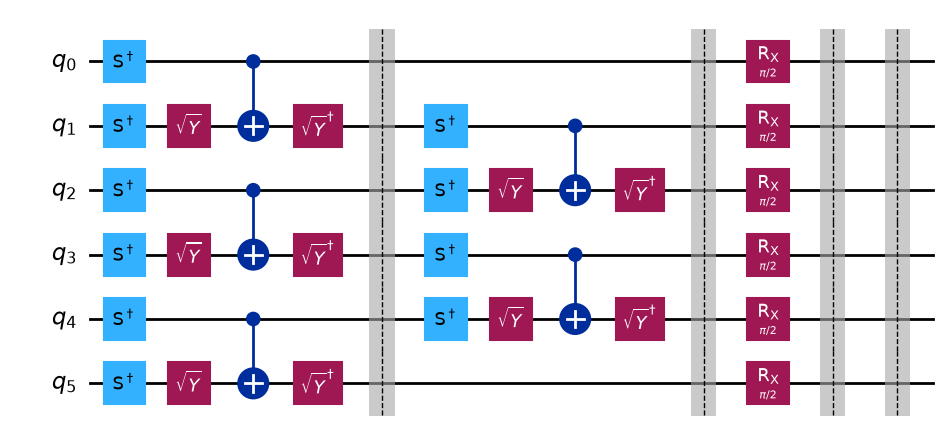

In [3]:
num_qbits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(num_qbits, num_trotter_steps, rx_angle, 0, trotter_barriers=True, layer_barriers=True)
qc.draw(output='mpl', fold=1)

In [4]:
#DEMO:SAMPLER

def append_mirrored_1d_tfim_circuit(qc,num_qubits,num_trotter_Steps, rx_angle, trotter_barriers = False, layer_barriers = False):

    for trotter_step in range(num_trotter_Steps):
        add_mirrored_1d_tfim_trotter_layer(qc, rx_angle, layer_barriers)
        if trotter_barriers:
            qc.barrier()


    return qc

def add_mirrored_1d_tfim_trotter_layer(qc, rx_angle,layer_barriers = False):
    #Adding Rzz gates in the even layers
    qc.rx(-rx_angle, list(range(qc.num_qubits)))
    if layer_barriers:
        qc.barrier()

#Adding Rzz in the odd layers
    for i in range(1,qc.num_qubits-1,2):
        
        qc.append(SYGate, [i+1])
        qc.cx(i,i+1)
        qc.append(SYdgGate, [i+1])
        qc.s([i,i+1])
    
    if layer_barriers:
        qc.barrier()

    #Adding Rzz in the odd layers

    for i in range(0,qc.num_qubits-1,2):
        
        qc.append(SYGate, [i+1])
        qc.cx(i,i+1)
        qc.append(SYdgGate, [i+1])
        qc.s([i,i+1])
    
    if layer_barriers:
        qc.barrier()


   

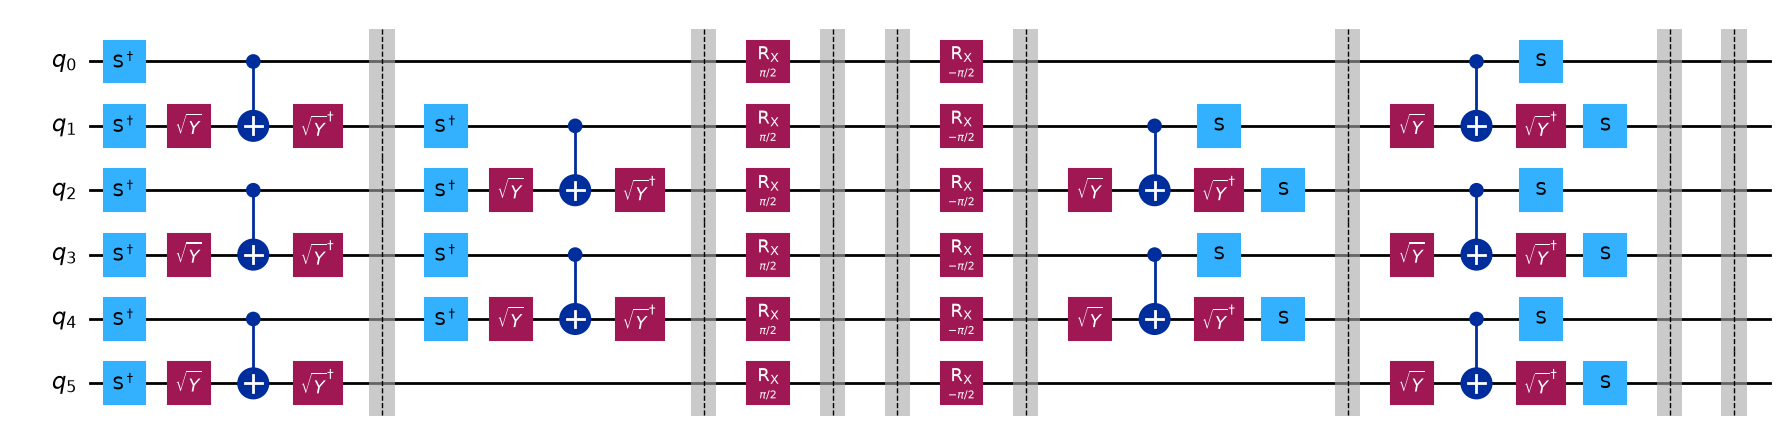

In [5]:
append_mirrored_1d_tfim_circuit(qc,num_qbits,num_trotter_steps, rx_angle, trotter_barriers=True, layer_barriers=True)
qc.draw(output='mpl', fold=-1)

In [6]:
#Step 1: Map the problem to circuits and observables

max_trotter_steps = 10
num_qbits = 8
measured_qubits = [4,5]
qc_list = []
for trotter_steps in range(1,max_trotter_steps):
    qc=generate_1d_tfim_circuit(num_qbits, trotter_steps, rx_angle,num_cl_bits=len(measured_qubits), trotter_barriers=True, layer_barriers=True)
    append_mirrored_1d_tfim_circuit(qc,num_qbits,trotter_steps, rx_angle, trotter_barriers=True, layer_barriers=True)
    qc.measure(measured_qubits, [0,1])
    qc_list.append(qc)

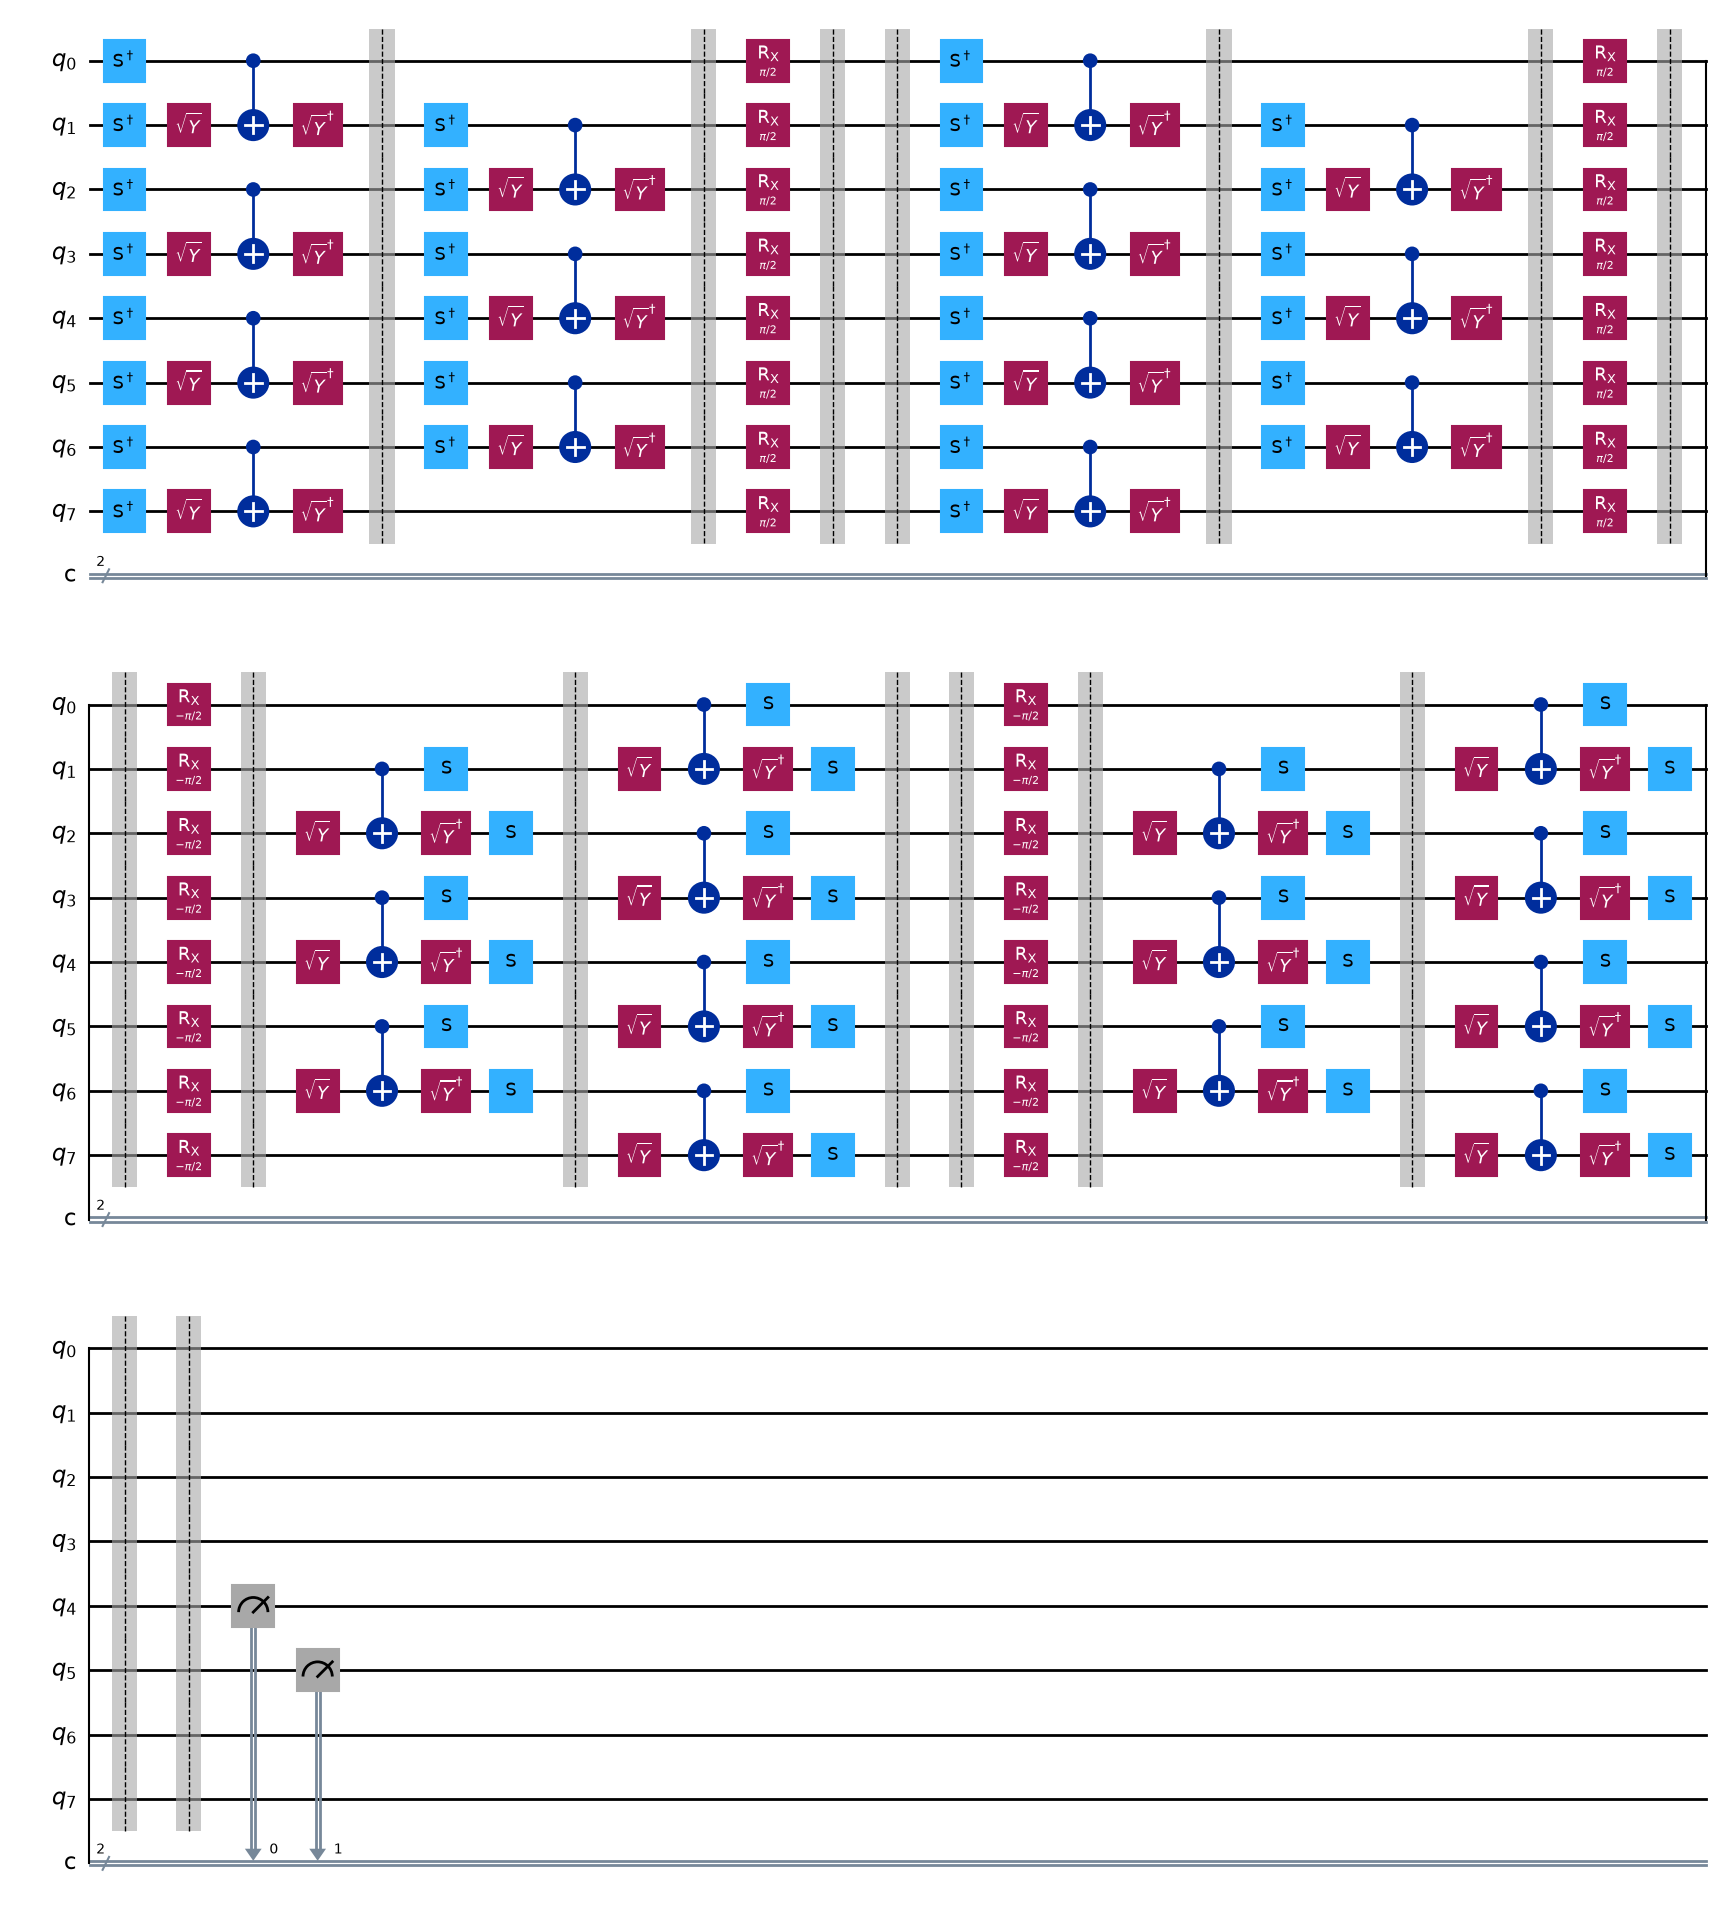

In [7]:
qc_list[1].draw(output='mpl')

In [ ]:
#STEP 2 Optimize
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False)
print(f"Backend name: {backend.name}"
    )

qc_Transpiled_list = transpile(qc_list, backend=backend, optimization_level=3)

In [ ]:
#Step 3 Execite on hardware

from qiskit_ibm_runtime import Sampler

sampler= Sampler(backend=backend)

sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence = "xy4"

job = sampler.run(qc_Transpiled_list)
print(job.job_id)

In [ ]:
#STEP 4 Post Processing and plotting


job_id = ""

job = service.job(job_id)
survival_probability_list= []
for trotter_steps in range(1,max_trotter_steps):
    try: 
        data= job.result()[trotter_steps].data
        survival_probability_list.append(data.c.get_count()['0'*len(measured_qubits)]/data.c.shots)
    except:
        survival_probability_list.append(0)


import matplotlib.pyplot as plt
plt.plot(list(range(0,4 * max_trotter_steps,4)), survival_probability_list)
plt.xlabel("20 Gate Depth")
plt.ylabel("Survival Probability")
plt.xticks(np.arange(0,44,4))
plt.show()


In [ ]:
#ESTIMATOR

#STEP 1: MAPPING THE PROBLEM



from qiskit.circuit import Parameter
rx_angle = Parameter("rx_angle")

trotter_steps = 2
qc.generate_1d_tfim_circuit(num_qbits, trotter_steps=2, rx_angle)

from qiskit.quantum_info import Statevector, SparsePauliOp, Pauli

middle_index=num_qbits//2

observable = SparsePauliOp('I' * middle_index + 'Z' + 'I' * (middle_index-1))


#STEP 2: OPTIMIZE THE CIRCUIT

from qiksit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = "ibmq_qasm_simulator"
service = QiskitRuntimeService()
backend = service.get_backend(backend_name)

qc_transpiled = transpile(qc, backend=backend, optimization_level=3)
observable = observable.apply_layout(qc_transpiled._layout)

#STEP 3: EXECUTE ON HARDWARE

from qiskit_ibm_runtime import EstimatorV2, EstimatorResult, EstimatorOptions

mix_rx_angle = 0
max_rx_angle = np.pi/2
num_rx_angle= 12
rx_angle_list = np.linspace(mix_rx_angle,max_rx_angle, num_rx_angle)

options= EstimatorOptions()
options.resilience_options = 1
options.dynamical_decoupling.enable ='True'
options.dynamical_decoupling.sequence_type = 'XY4'

estimator= EstimatorV2(backend=backend, options=options)

job = estimator.run([qc_transpiled, observable, rx_angle_list])

print(job.job_id())


#STEP 4 Post Processing and plotting

job_id = ''
job=service.job(job_id)

exp_val_list = job.result()[0]

plt.plot(rx_angle/np.pi, exp_val_list, '--o')
plt.xlabel(r'Rx angle ($\pi$)')
plt.ylabel('$\langle Z \rangle in the middle of the chain')

plt.ylim(-0.1, 1.1)